In this project, we develop a deep learning based system for automatic brain tumor segmentation using the BraTS 2021 dataset. Multi-modal 3D MRI volumes and their corresponding ground-truth segmentation masks are preprocessed by extracting axial 2D slices, normalizing intensity values, and resizing the images to a fixed resolution. For simplicity, a single MRI modality is used and the segmentation task is formulated as a binary classification problem distinguishing tumor and non-tumor regions. A U-Net architecture is implemented to perform pixel-wise segmentation of tumor regions from MRI slices. The model is trained on paired image mask data and evaluated using Dice Score and Intersection over Union (IoU) metrics. Finally, qualitative results are visualized by comparing the predicted segmentation masks with the ground-truth annotations to assess the model performance.

In [1]:
!pip install nibabel opencv-python tqdm


imports

In [18]:
import os
import numpy as np
import cv2
import nibabel as nib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm


device check








In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

enabled gpu!!!!!

In [20]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cuda')

gpu details below

In [21]:
!nvidia-smi


Mon Jan  5 14:37:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [22]:
!ls /content


BraTS2021  sample_data


In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brats-2021-task1' dataset.
Path to dataset files: /kaggle/input/brats-2021-task1


In [8]:
ls /kaggle/input/brats-2021-task1


BraTS2021_00495.tar  BraTS2021_00621.tar  BraTS2021_Training_Data.tar


In [9]:
!mkdir -p /content/BraTS2021


In [10]:
!tar -xf /kaggle/input/brats-2021-task1/BraTS2021_Training_Data.tar -C /content/BraTS2021


In [11]:
!ls /content/BraTS2021 | head


BraTS2021_00000
BraTS2021_00002
BraTS2021_00003
BraTS2021_00005
BraTS2021_00006
BraTS2021_00008
BraTS2021_00009
BraTS2021_00011
BraTS2021_00012
BraTS2021_00014


In [12]:
!ls /content/BraTS2021/BraTS2021_00000


BraTS2021_00000_flair.nii.gz  BraTS2021_00000_t1.nii.gz
BraTS2021_00000_seg.nii.gz    BraTS2021_00000_t2.nii.gz
BraTS2021_00000_t1ce.nii.gz


In [13]:
BRATS_PATH = "/content/BraTS2021"


Define load_patient_slices

In [37]:
import nibabel as nib
import numpy as np
import cv2

def load_patient_slices(flair_path, mask_path, img_size=256):
    flair = nib.load(flair_path).get_fdata()
    mask  = nib.load(mask_path).get_fdata()

    images = []
    masks  = []

    for i in range(flair.shape[2]):
        img = flair[:, :, i]
        msk = mask[:, :, i]

        if np.max(msk) == 0:
            continue

        img = cv2.resize(img, (img_size, img_size))
        msk = cv2.resize(msk, (img_size, img_size))

        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        msk = (msk > 0).astype(np.float32)

        images.append(img)
        masks.append(msk)

    return images, masks


Load MRI slices

In [30]:
import os

all_images = []
all_masks  = []

patient_dirs = sorted([
    d for d in os.listdir(BRATS_PATH)
    if os.path.isdir(os.path.join(BRATS_PATH, d))
])[:10]

for p in patient_dirs:
    p_path = os.path.join(BRATS_PATH, p)

    flair_file = [f for f in os.listdir(p_path) if "flair" in f][0]
    mask_file  = [f for f in os.listdir(p_path) if "seg" in f][0]

    imgs, msks = load_patient_slices(
        os.path.join(p_path, flair_file),
        os.path.join(p_path, mask_file)
    )

    all_images.extend(imgs)
    all_masks.extend(msks)

print("Total slices loaded:", len(all_images))


Total slices loaded: 620


creating dataset and dataloader

In [31]:
from torch.utils.data import Dataset, DataLoader
import torch

class BraTSDataset(Dataset):
    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = torch.tensor(self.images[idx], dtype=torch.float32)
        mask = torch.tensor(self.masks[idx], dtype=torch.float32)
        return img, mask
dataset = BraTSDataset(all_images, all_masks)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2
)

print("Number of batches:", len(loader))


Number of batches: 78


defining u-net

In [32]:
import torch.nn as nn

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.ReLU(inplace=True)
            )

        self.enc1 = block(1, 64)
        self.enc2 = block(64, 128)
        self.pool = nn.MaxPool2d(2)

        self.middle = block(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, 2)
        self.dec2 = block(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, 2)
        self.dec1 = block(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        m  = self.middle(self.pool(e2))

        d2 = self.up2(m)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out(d1))


model, loss, optimizer

In [33]:
model = UNet().to(device)

criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


model training

In [34]:
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0.0

    for imgs, masks in loader:
        imgs = imgs.unsqueeze(1).to(device)
        masks = masks.unsqueeze(1).to(device)

        preds = model(imgs)
        loss = criterion(preds, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss/len(loader):.4f}")


Epoch 1/5 | Loss: 0.3149
Epoch 2/5 | Loss: 0.0566
Epoch 3/5 | Loss: 0.0488
Epoch 4/5 | Loss: 0.0458
Epoch 5/5 | Loss: 0.0441


Dice and IoU

In [35]:
def dice_score(pred, target):
    smooth = 1e-5
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    return (2 * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def iou_score(pred, target):
    pred = (pred > 0.5).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    return intersection / (union + 1e-5)
model.eval()

imgs, masks = next(iter(loader))
imgs = imgs.unsqueeze(1).to(device)
masks = masks.unsqueeze(1).to(device)

with torch.no_grad():
    preds = model(imgs)

print("Dice Score:", dice_score(preds, masks).item())
print("IoU Score :", iou_score(preds, masks).item())


Dice Score: 0.7654061913490295
IoU Score : 0.6199660301208496


Visualisation

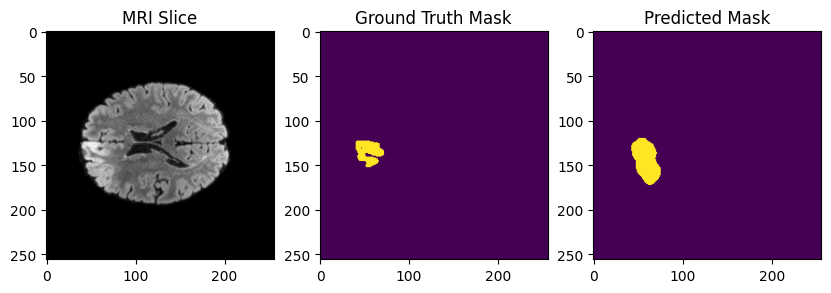

In [36]:
import matplotlib.pyplot as plt

img = imgs[0,0].cpu()
gt  = masks[0,0].cpu()
pr  = preds[0,0].cpu()

plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
plt.title("MRI Slice")
plt.imshow(img, cmap="gray")

plt.subplot(1,3,2)
plt.title("Ground Truth Mask")
plt.imshow(gt)

plt.subplot(1,3,3)
plt.title("Predicted Mask")
plt.imshow(pr > 0.5)

plt.show()


Closing statement - A U-Net–based deep learning model was implemented for automatic brain tumor segmentation using the BraTS 2021 dataset. MRI volumes were preprocessed by extracting axial 2D slices, normalizing intensities, and converting segmentation labels into binary masks. The model was trained using binary cross-entropy loss and evaluated using Dice Score and Intersection over Union metrics. Visual comparisons between predicted segmentation masks and ground-truth annotations demonstrate effective tumor localization and segmentation performance.